## LABORATORIO 2

Nuria Arroyo Bustamante 

Apredizaje de Máquina  - Otoño 2025

Dr. Hector Saib Gómez Maravillo 



*Instrucciones.*

1.- Elige una base de datos, la única restricción es que éstos datos no pueden corresponder a vectores de R^n o Z^n.

2.- Elige una función de disimilitud o similitud adecuada para el tipo de dato seleccionado.

3.- Implementa en Python un algoritmo para calcular la matriz de disimilitud o similitud entre todos los pares de elementos.

4.- No puedes usar las funciones pdist ni cdist, pero si puedes usar las demas funciones de librerias de Scipy o Numpy.

5.- Exporta la matriz de disimilitud o similitud como un archivo csv.

6.- Utiliza la matriz construida para realizar reducción de dimensionalidad a R^2, utilizando algún método adecuado (MDS, ISOMAP, T-SNE, UMAP) y crea la gráfica de dispersión de su incrustación.



Producto esperado:

Un archivo .py o un cuaderno .ipynb que contenga:

La implementación en Python del cálculo de la matriz de disimilitud o similitud.
Documentación adecuada del código.
Un archivo .zip que contenga la matriz de disimilitud o similitud calculada.

Una gráfica de dispersión de la reducción de dimensionalidad.

In [1]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import pubchempy as pcp
from rdkit.Chem import rdchem
from collections import Counter
import numpy as np
import umap.umap_ as umap



Se utñiliza el codigo compartido por el profesor para la extraccion de la base de datos. 

In [2]:

# Establecer ruta de acceso a los datos

name = "NPASSv2.0_structureInfo.txt"

npass = pd.read_csv(name, sep="\t", na_values="n.a.")

# Convertir SMILE a FingerPrint
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
def smiles_to_fp(smile):
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        return None
    fp = morgan_gen.GetFingerprint(mol)
    return fp
fps = npass["SMILES"].apply(smiles_to_fp)
npass["FingerPrint"] = fps

# haha este codigo me da la fp que es el binario con 1024 bits

[01:27:34] Explicit valence for atom # 15 S, 7, is greater than permitted
[01:27:34] Explicit valence for atom # 8 N, 4, is greater than permitted
[01:27:35] Explicit valence for atom # 5 N, 5, is greater than permitted
[01:27:36] Explicit valence for atom # 1 N, 4, is greater than permitted
[01:27:36] Explicit valence for atom # 1 N, 5, is greater than permitted
[01:27:36] Explicit valence for atom # 7 N, 5, is greater than permitted
[01:27:36] Explicit valence for atom # 6 N, 5, is greater than permitted
[01:27:38] Explicit valence for atom # 21 N, 4, is greater than permitted
[01:27:38] Explicit valence for atom # 6 N, 4, is greater than permitted
[01:27:38] Explicit valence for atom # 14 N, 5, is greater than permitted
[01:27:39] Explicit valence for atom # 8 N, 4, is greater than permitted
[01:27:40] WARNING: not removing hydrogen atom without neighbors
[01:27:41] Explicit valence for atom # 31 N, 5, is greater than permitted
[01:27:41] Explicit valence for atom # 20 N, 4, is grea

In [3]:
npass

,np_id,InChI,InChIKey,SMILES,FingerPrint
0,NPC81384,"InChI=1S/C8H20NO6P/c1-9(2,3)4-5-14-16(12,13)15...",SUHOQUVVVLNYQR-MRVPVSSYSA-N,OC[C@H](COP(=O)(OCC[N+](C)(C)C)[O-])O,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ..."
1,NPC109991,InChI=1S/C24H21NO5/c1-3-13(2)21(24(29)30)25-12...,RVOHRYJJXCFNQS-YEJXKQKISA-N,CC[C@H](C)[C@H](C(=O)O)n1cc2C=C(C(=O)c3c(ccc(c...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,NPC4649,InChI=1S/C20H20O7/c1-5-6-14(22)26-19-18(24-11(...,MHLKYRDXNNGAMX-WLMAVBAVSA-N,C/C=C/C(=O)O[C@H]1[C@H](c2c(ccc3ccc(=O)oc23)OC...,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, ..."
3,NPC90844,InChI=1S/C23H25NO3/c1-25-15-6-7-16-18(10-15)20...,NCVWJDISIZHFQS-AWEZNQCLSA-N,COc1ccc2c(c1)c1cc(c(cc1c1C[C@@H]3CCCN3Cc21)OC)OC,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,NPC18064,InChI=1S/C30H48O3/c1-18-10-15-30(25(32)33)17-1...,HNJKFVJZKCXLRL-SILQXMKOSA-N,CC1=CC[C@]2([C@H]([C@@H]1C)[C@H]1CC[C@H]3[C@@]...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...
96230,NPC490923,InChI=1S/C8H9NO2/c1-9-7-5-3-2-4-6(7)8(10)11/h2...,WVMBPWMAQDVZCM-UHFFFAOYSA-M,CNC1=CC=CC=C1C(=O)[O-],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
96231,NPC478028,InChI=1S/C95H125N23O24S2/c1-7-48(4)78-93(139)1...,VXOKYTDMQDFAQT-VJFZWUEESA-N,CC[C@H](C)[C@H]1C(=O)N2CCC[C@H]2C(=O)NCC(=O)N[...,"[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
96232,NPC478029,InChI=1S/C96H127N23O24S2/c1-8-49(4)79-94(140)1...,DIYKCNUJDOKJCM-FZVOVPNHSA-N,CC[C@H](C)[C@H]1C(=O)N2CCC[C@H]2C(=O)NCC(=O)N[...,"[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
96233,NPC490681,InChI=1S/C9H9NO4/c11-8(12)5-10-7-4-2-1-3-6(7)9...,PJUXPMVQAZLJEX-UHFFFAOYSA-N,O=C(O)CNC1=CC=CC=C1C(=O)O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [4]:
#pasar a un grafo el smiles
def smiles_to_graph(smile):
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        return None
    G = nx.Graph()
    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(),atomic_num=atom.GetAtomicNum(),
                   is_aromatic=atom.GetIsAromatic(),
                   atom_symbol=atom.GetSymbol())
        
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(), bond_type=bond.GetBondType())
    return G, mol


En esta secciond el código se busca entender la estructura resultente de un compuesto químico a partir de su representación SMILES. Se convierte la representación SMILES en un grafo utilizando la librería RDKit, y luego se visualiza el grafo con colores que representan diferentes tipos de átomos. Además, se extraen y muestran los tipos de enlaces presentes en el grafo.

[(0, {'atomic_num': 6, 'is_aromatic': False, 'atom_symbol': 'C'}), (1, {'atomic_num': 6, 'is_aromatic': False, 'atom_symbol': 'C'}), (2, {'atomic_num': 8, 'is_aromatic': False, 'atom_symbol': 'O'}), (3, {'atomic_num': 7, 'is_aromatic': False, 'atom_symbol': 'N'}), (4, {'atomic_num': 6, 'is_aromatic': True, 'atom_symbol': 'C'}), (5, {'atomic_num': 6, 'is_aromatic': True, 'atom_symbol': 'C'}), (6, {'atomic_num': 6, 'is_aromatic': True, 'atom_symbol': 'C'}), (7, {'atomic_num': 6, 'is_aromatic': True, 'atom_symbol': 'C'}), (8, {'atomic_num': 6, 'is_aromatic': True, 'atom_symbol': 'C'}), (9, {'atomic_num': 6, 'is_aromatic': True, 'atom_symbol': 'C'}), (10, {'atomic_num': 8, 'is_aromatic': False, 'atom_symbol': 'O'})]
[(0, 1, {'bond_type': rdkit.Chem.rdchem.BondType.SINGLE}), (1, 2, {'bond_type': rdkit.Chem.rdchem.BondType.DOUBLE}), (1, 3, {'bond_type': rdkit.Chem.rdchem.BondType.SINGLE}), (3, 4, {'bond_type': rdkit.Chem.rdchem.BondType.SINGLE}), (4, 5, {'bond_type': rdkit.Chem.rdchem.BondTy

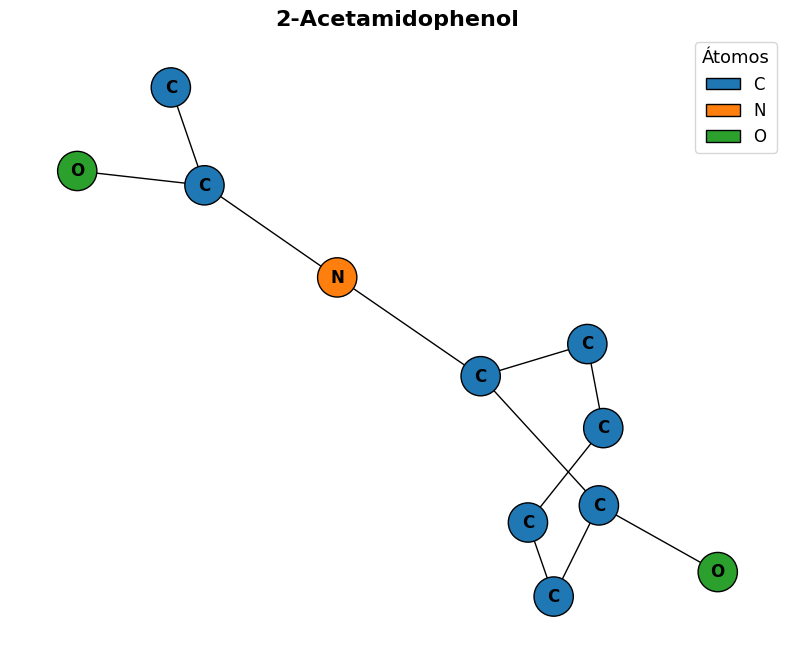

In [5]:
smile = npass.loc[96229 , "SMILES"]
G, mol = smiles_to_graph(smile)
#ver que datos tiene el grafo
print(G.nodes(data=True))
print(G.edges(data=True))

# Visualizar el grafo con colores por tipo de átomo
atom_labels = {atom.GetIdx(): atom.GetSymbol() for atom in mol.GetAtoms()}
inchikey = npass.loc[96229, "InChIKey"]
compound = pcp.get_compounds(inchikey, namespace='inchikey')


cmap = plt.get_cmap("tab10")  

# asignar un color a cada tipo de átomo
unique_atoms = sorted(set(atom_labels.values()))
atom_to_color = {atom: cmap(i % cmap.N) for i, atom in enumerate(unique_atoms)}
node_colors = [atom_to_color[atom_labels[idx]] for idx in G.nodes()]


fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    labels={k: f"{v}" for k, v in atom_labels.items()},
    with_labels=True,
    node_color=node_colors,
    node_size=800,
    font_weight='bold',
    font_size=12,
    edgecolors='black',
    ax=ax
)

#titulo con el nombre del compuesto
ax.set_title(
    compound[0].synonyms[0] if compound and compound[0].synonyms else (
        compound[0].iupac_name if compound and compound[0].iupac_name else "No synonym found"
    ),
    fontweight='bold',
    fontsize=16
)

# leyenda colores por tipo de átomo
legend_elements = [
    Patch(facecolor=atom_to_color[atom], edgecolor='black', label=atom)
    for atom in unique_atoms
]
ax.legend(handles=legend_elements, title="Átomos", title_fontsize=13, fontsize=12, loc='upper right', frameon=True)




In [6]:
#convertir todos los smiles a grafos
graphs = npass["SMILES"].apply(smiles_to_graph)
npass["Graph"] = graphs

[01:28:00] Explicit valence for atom # 15 S, 7, is greater than permitted
[01:28:01] Explicit valence for atom # 8 N, 4, is greater than permitted
[01:28:03] Explicit valence for atom # 5 N, 5, is greater than permitted
[01:28:04] Explicit valence for atom # 1 N, 4, is greater than permitted
[01:28:05] Explicit valence for atom # 1 N, 5, is greater than permitted
[01:28:05] Explicit valence for atom # 7 N, 5, is greater than permitted
[01:28:06] Explicit valence for atom # 6 N, 5, is greater than permitted
[01:28:09] Explicit valence for atom # 21 N, 4, is greater than permitted
[01:28:09] Explicit valence for atom # 6 N, 4, is greater than permitted
[01:28:09] Explicit valence for atom # 14 N, 5, is greater than permitted
[01:28:10] Explicit valence for atom # 8 N, 4, is greater than permitted
[01:28:12] WARNING: not removing hydrogen atom without neighbors
[01:28:14] Explicit valence for atom # 31 N, 5, is greater than permitted
[01:28:15] Explicit valence for atom # 20 N, 4, is grea

In [7]:
npass

,np_id,InChI,InChIKey,SMILES,FingerPrint,Graph
0,NPC81384,"InChI=1S/C8H20NO6P/c1-9(2,3)4-5-14-16(12,13)15...",SUHOQUVVVLNYQR-MRVPVSSYSA-N,OC[C@H](COP(=O)(OCC[N+](C)(C)C)[O-])O,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
1,NPC109991,InChI=1S/C24H21NO5/c1-3-13(2)21(24(29)30)25-12...,RVOHRYJJXCFNQS-YEJXKQKISA-N,CC[C@H](C)[C@H](C(=O)O)n1cc2C=C(C(=O)c3c(ccc(c...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
2,NPC4649,InChI=1S/C20H20O7/c1-5-6-14(22)26-19-18(24-11(...,MHLKYRDXNNGAMX-WLMAVBAVSA-N,C/C=C/C(=O)O[C@H]1[C@H](c2c(ccc3ccc(=O)oc23)OC...,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
3,NPC90844,InChI=1S/C23H25NO3/c1-25-15-6-7-16-18(10-15)20...,NCVWJDISIZHFQS-AWEZNQCLSA-N,COc1ccc2c(c1)c1cc(c(cc1c1C[C@@H]3CCCN3Cc21)OC)OC,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
4,NPC18064,InChI=1S/C30H48O3/c1-18-10-15-30(25(32)33)17-1...,HNJKFVJZKCXLRL-SILQXMKOSA-N,CC1=CC[C@]2([C@H]([C@@H]1C)[C@H]1CC[C@H]3[C@@]...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
...,...,...,...,...,...,...
96230,NPC490923,InChI=1S/C8H9NO2/c1-9-7-5-3-2-4-6(7)8(10)11/h2...,WVMBPWMAQDVZCM-UHFFFAOYSA-M,CNC1=CC=CC=C1C(=O)[O-],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10), <rdkit.Ch..."
96231,NPC478028,InChI=1S/C95H125N23O24S2/c1-7-48(4)78-93(139)1...,VXOKYTDMQDFAQT-VJFZWUEESA-N,CC[C@H](C)[C@H]1C(=O)N2CCC[C@H]2C(=O)NCC(=O)N[...,"[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
96232,NPC478029,InChI=1S/C96H127N23O24S2/c1-8-49(4)79-94(140)1...,DIYKCNUJDOKJCM-FZVOVPNHSA-N,CC[C@H](C)[C@H]1C(=O)N2CCC[C@H]2C(=O)NCC(=O)N[...,"[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
96233,NPC490681,InChI=1S/C9H9NO4/c11-8(12)5-10-7-4-2-1-3-6(7)9...,PJUXPMVQAZLJEX-UHFFFAOYSA-N,O=C(O)CNC1=CC=CC=C1C(=O)O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."


In [8]:
# Listar todos los atributos válidos de BondType
for attr in dir(rdchem.BondType):
    if not attr.startswith('_'):  # Ignora atributos internos
        value = getattr(rdchem.BondType, attr)
        if isinstance(value, rdchem.BondType):
            print(f"{attr:15} → internal int: {int(value)}")

AROMATIC        → internal int: 12
DATIVE          → internal int: 17
DATIVEL         → internal int: 18
DATIVEONE       → internal int: 16
DATIVER         → internal int: 19
DOUBLE          → internal int: 2
FIVEANDAHALF    → internal int: 11
FOURANDAHALF    → internal int: 10
HEXTUPLE        → internal int: 6
HYDROGEN        → internal int: 14
IONIC           → internal int: 13
ONEANDAHALF     → internal int: 7
OTHER           → internal int: 20
QUADRUPLE       → internal int: 4
QUINTUPLE       → internal int: 5
SINGLE          → internal int: 1
THREEANDAHALF   → internal int: 9
THREECENTER     → internal int: 15
TRIPLE          → internal int: 3
TWOANDAHALF     → internal int: 8
UNSPECIFIED     → internal int: 0
ZERO            → internal int: 21


In [9]:
# crear un diccionario para mapear los tipos de enlace a enteros
BOND_MAP = {
    'SINGLE': 1, 'DOUBLE': 2, 'TRIPLE': 3, 'AROMATIC': 12,
    'QUADRUPLE': 4, 'QUINTUPLE': 5, 'HEXTUPLE': 6,
    'ONEANDAHALF': 7, 'TWOANDAHALF': 8, 'THREEANDAHALF': 9,
    'FOURANDAHALF': 10, 'FIVEANDAHALF': 11,
    'IONIC': 13, 'HYDROGEN': 14, 'THREECENTER': 15,
    'DATIVEONE': 16, 'DATIVE': 17, 'DATIVEL': 18, 'DATIVER': 19,
    'OTHER': 20, 'UNSPECIFIED': 0, 'ZERO': 21
}


Para la implementación de la función de similitud, se utiliza el algoritmo de Weisfeiler-Lehman (WL) que es un método popular para comparar grafos. Este algoritmo asigna etiquetas a los nodos del grafo basándose en sus características y las de sus vecinos, y luego utiliza estas etiquetas para calcular una representación vectorial del grafo. La similitud entre dos grafos se puede medir utilizando la similitud de Tanimoto entre sus representaciones vectoriales.

In [10]:
#de la informacion de clarada en la función smiles_to_graph se pueden obtener las siguientes funciones
# información de los nodos (tipo de átomo, si es aromático)
def initial_node_label(G, v):
        a = G.nodes[v]
        return f"{a['atomic_num']}{'A' if a.get('is_aromatic') else ''}"

# información de las aristas (tipo de enlace) de el diccionario BOND_MAP
def bond_label(edge_data):
    bt = edge_data.get('bond_type')
    name = getattr(bt, 'name', str(bt))
    return BOND_MAP.get(name, BOND_MAP['OTHER'])


In [11]:
# función de actualización de etiquetas que considera los tipos de enlace el algoritmo de Weisfeiler-Lehman 1 sola iteracion
def wl_con_edges(G, labels):
    new_labels = {}
    for v in G.nodes():
        neigh_sig = []
        for u in G.neighbors(v):
            el = bond_label(G[v][u])    
            nl = labels[u]               
            neigh_sig.append((el, nl))   
        neigh_sig.sort()
        new_labels[v] = (labels[v], tuple(neigh_sig))  
    return new_labels


In [12]:

#  Etiquetas WL por niveles va a llamando a wl_con_edges que hace una iteracion
def wl_labels(G, h=2):
    labels = {v: initial_node_label(G, v) for v in G.nodes()}
    all_label_multisets = [list(labels.values())] 
    for _ in range(h):
        labels = wl_con_edges(G, labels)
        all_label_multisets.append(list(labels.values()))
    return all_label_multisets



In [13]:
#ejemolplo de uso de labels o la lsiata de labels 
label= wl_labels(G, h=2)
label

[['6', '6', '8', '7', '6A', '6A', '6A', '6A', '6A', '6A', '8'],
 [('6', ((1, '6'),)),
  ('6', ((1, '6'), (1, '7'), (2, '8'))),
  ('8', ((2, '6'),)),
  ('7', ((1, '6'), (1, '6A'))),
  ('6A', ((1, '7'), (12, '6A'), (12, '6A'))),
  ('6A', ((12, '6A'), (12, '6A'))),
  ('6A', ((12, '6A'), (12, '6A'))),
  ('6A', ((12, '6A'), (12, '6A'))),
  ('6A', ((12, '6A'), (12, '6A'))),
  ('6A', ((1, '8'), (12, '6A'), (12, '6A'))),
  ('8', ((1, '6A'),))],
 [(('6', ((1, '6'),)), ((1, ('6', ((1, '6'), (1, '7'), (2, '8')))),)),
  (('6', ((1, '6'), (1, '7'), (2, '8'))),
   ((1, ('6', ((1, '6'),))),
    (1, ('7', ((1, '6'), (1, '6A')))),
    (2, ('8', ((2, '6'),))))),
  (('8', ((2, '6'),)), ((2, ('6', ((1, '6'), (1, '7'), (2, '8')))),)),
  (('7', ((1, '6'), (1, '6A'))),
   ((1, ('6', ((1, '6'), (1, '7'), (2, '8')))),
    (1, ('6A', ((1, '7'), (12, '6A'), (12, '6A')))))),
  (('6A', ((1, '7'), (12, '6A'), (12, '6A'))),
   ((1, ('7', ((1, '6'), (1, '6A')))),
    (12, ('6A', ((1, '8'), (12, '6A'), (12, '6A')))),


In [14]:
#fucnion para convertir las etiquetas wl a un contador de etiquetas
def wl_vector(G, h=2):
    labels_by_level = wl_labels(G, h=h)  
    fp = Counter()
    for labels in labels_by_level:
        fp.update(labels)
    return fp


In [15]:
fp = wl_vector(G, h=2)
labels = [str(label) for label in fp.keys()]
counts = list(fp.values())
fp

Counter({'6A': 6,
         ('6A', ((12, '6A'), (12, '6A'))): 4,
         '6': 2,
         '8': 2,
         (('6A', ((12, '6A'), (12, '6A'))),
          ((12, ('6A', ((12, '6A'), (12, '6A')))),
           (12, ('6A', ((12, '6A'), (12, '6A')))))): 2,
         '7': 1,
         ('6', ((1, '6'),)): 1,
         ('6', ((1, '6'), (1, '7'), (2, '8'))): 1,
         ('8', ((2, '6'),)): 1,
         ('7', ((1, '6'), (1, '6A'))): 1,
         ('6A', ((1, '7'), (12, '6A'), (12, '6A'))): 1,
         ('6A', ((1, '8'), (12, '6A'), (12, '6A'))): 1,
         ('8', ((1, '6A'),)): 1,
         (('6', ((1, '6'),)),
          ((1, ('6', ((1, '6'), (1, '7'), (2, '8')))),)): 1,
         (('6', ((1, '6'), (1, '7'), (2, '8'))),
          ((1, ('6', ((1, '6'),))),
           (1, ('7', ((1, '6'), (1, '6A')))),
           (2, ('8', ((2, '6'),))))): 1,
         (('8', ((2, '6'),)),
          ((2, ('6', ((1, '6'), (1, '7'), (2, '8')))),)): 1,
         (('7', ((1, '6'), (1, '6A'))),
          ((1, ('6', ((1, '6'), (1, '7

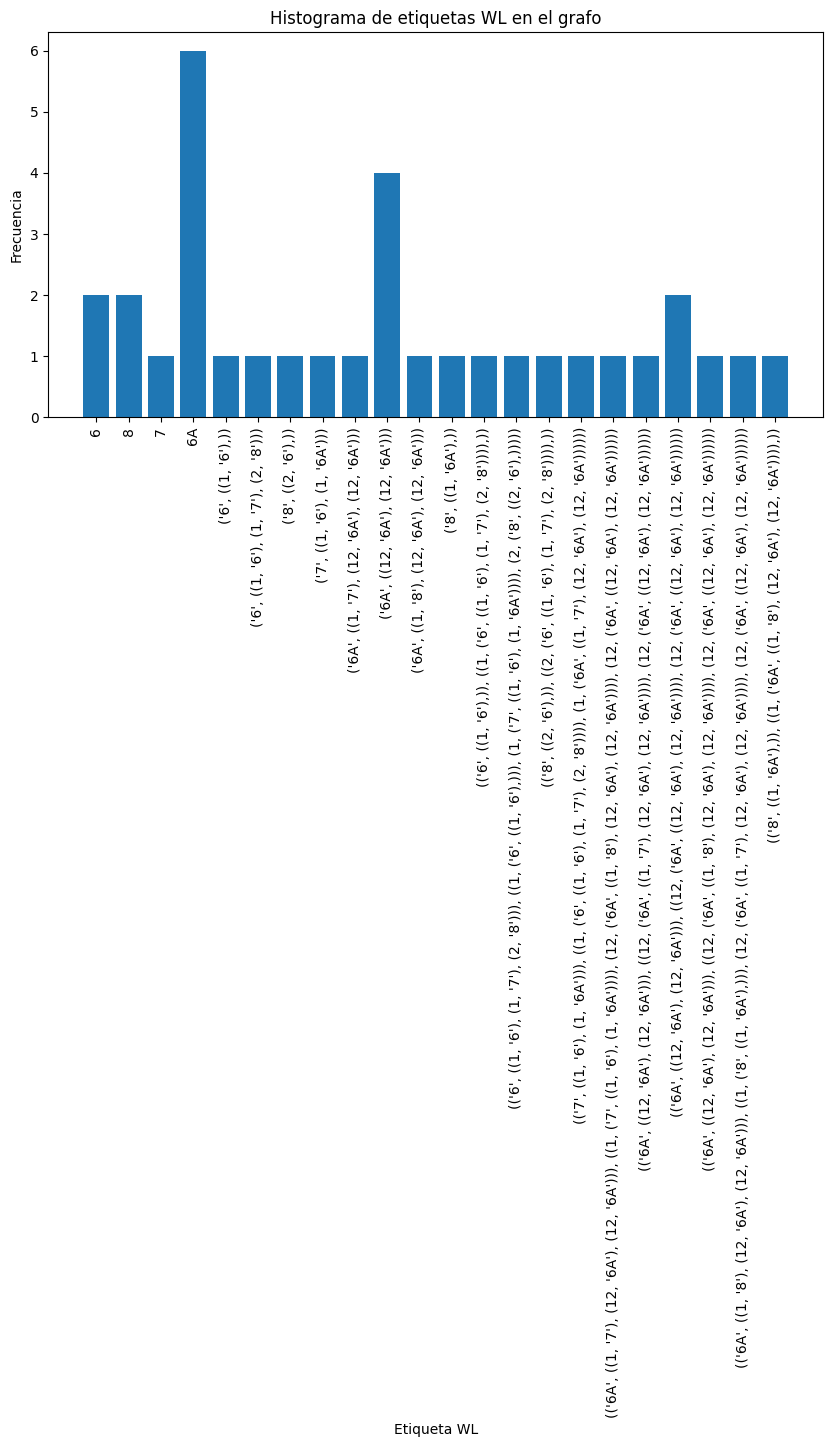

In [16]:
plt.figure(figsize=(10,5))
plt.bar(labels, counts)
plt.xticks(rotation=90)
plt.xlabel("Etiqueta WL")
plt.ylabel("Frecuencia")
plt.title("Histograma de etiquetas WL en el grafo")
plt.show()

In [17]:

def tanimoto_conteo(fp1: Counter, fp2: Counter) -> float:
    if not fp1 and not fp2:
        return 1.0
    keys = set(fp1) | set(fp2) # todas las labels de ambos grafos
    dot   = sum(fp1.get(k, 0.0) * fp2.get(k, 0.0) for k in keys) # producto punto de los vectores de frecuesncia 
    norm1 = sum(v*v for v in fp1.values()) # norma al cuadrado del primer vector
    norm2 = sum(v*v for v in fp2.values()) # norma al cuadrado del segundo vector
    denom = norm1 + norm2 - dot
    return 0.0 if denom == 0 else float(dot / denom)

#función para llamaor a todo wrapear directo
def wl_tanimoto(G1, G2, h=2):
    fp1 = wl_vector(G1, h=h)
    fp2 = wl_vector(G2, h=h)
    return tanimoto_conteo(fp1, fp2)


In [18]:
g1 = npass.loc[0, "Graph"][0]
g2 = npass.loc[1, "Graph"][0]

wl_tanimoto(g1, g2, h=2)

0.20784313725490197

In [38]:
npass["Graph"].isnull().sum()


np.int64(0)

In [37]:
npass = npass.dropna(subset=["Graph"])


In [39]:
#seleccionar 1000 aleatoria filas para hacer la matriz de similitud
subset = npass.sample(1000, random_state=42).reset_index(drop=True)

In [40]:
subset

,np_id,InChI,InChIKey,SMILES,FingerPrint,Graph
0,NPC117411,"InChI=1S/C2H4O2/c1-4-2-3/h2H,1H3",TZIHFWKZFHZASV-UHFFFAOYSA-N,COC=O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","((0, 1, 2, 3), <rdkit.Chem.rdchem.Mol object a..."
1,NPC304476,InChI=1S/C18H26O9/c1-23-11-7-10(8-12(24-2)17(1...,SGVIOKXMBPTKTD-MRRGJRPVSA-N,COc1cc(/C=C/CO[C@H]2[C@@H]([C@@H]([C@@H]([C@H]...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
2,NPC105025,InChI=1S/C22H22O11/c1-30-21-14(32-22-20(29)19(...,GCLAFEGUXXHIFT-IWLDQSELSA-N,COc1c(cc2c(c(=O)cc(c3ccc(cc3)O)o2)c1O)O[C@H]1[...,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
3,NPC263233,InChI=1S/C29H24O10S/c30-17-11-20(33)24-23(12-1...,RWMMKPIAMOVOIH-PKTNWEFCSA-N,c1ccc(cc1)CS[C@H]1c2c(cc(cc2O[C@H](c2ccc(c(c2)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
4,NPC472040,InChI=1S/C19H23ClO6/c1-11-7-8-12(21)5-3-4-6-13...,LUNPQPBTPNQDSU-JZYUNNQISA-N,CC1CCC(CCC=CC(=O)CC2=C(C(=CC(=C2C(=O)O1)OC)O)Cl)O,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
...,...,...,...,...,...,...
995,NPC72981,InChI=1S/C35H36N2O6/c1-37-13-11-22-17-30(40-2)...,CAPNACHMCYSNMC-RRPNLBNLSA-N,CN1CCc2cc(c3cc2[C@H]1Cc1ccc(cc1)Oc1cc(ccc1O)C[...,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
996,NPC316705,InChI=1S/C40H72N7O17P3S/c1-25(2)11-8-12-26(3)1...,XYJPSQPVCBNZHT-TUKYSRJDSA-N,CC(C)CCCC(C)CCCC(C)CCCC(C)C(=O)SCCNC(=O)CCNC(=...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
997,NPC480472,InChI=1S/C37H38O21/c1-51-20-9-14(3-6-17(20)40)...,XBXPWZFHCUFBQM-YJCKAOSSSA-N,COc1cc(ccc1O)/C=C/C(=O)OC([C@]1(CO[C@H]([C@@H]...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
998,NPC472877,InChI=1S/C21H14O6/c22-10-11-5-17(26)20-18(6-11...,QZAVIALHBJNTGA-UHFFFAOYSA-N,C1=CC(=CC=C1C2=C(C3=C(C=C(C=C3O2)C=O)O)C4=CC(=...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."


In [41]:


matriz_similitud = np.zeros((len(subset), len(subset)))

for i in range(len(subset)):
    g1 = subset.iloc[i]["Graph"]
    if isinstance(g1, (list, tuple)): 
        g1 = g1[0]
    for j in range(i, len(subset)):
        g2 = subset.iloc[j]["Graph"]
        if isinstance(g2, (list, tuple)): 
            g2 = g2[0]

        if g1 is None or g2 is None:
            sim = np.nan   # o 0.0 si prefieres
        else:
            sim = wl_tanimoto(g1, g2, h=2)

        matriz_similitud[i, j] = sim
        matriz_similitud[j, i] = sim


In [28]:
#construir la matriz de la medida de similitud entre los compuestos 
matriz_similitud = np.zeros((len(subset), len(subset)))
for i in range(len(subset)):
    g1 = subset.loc[i, "Graph"][0]
    for j in range(i, len(subset)):
        g2 = subset.loc[j, "Graph"][0]
        sim = wl_tanimoto(g1, g2, h=2)
        matriz_similitud[i, j] = sim
        matriz_similitud[j, i] = sim  # La matriz es simétrica

TypeError: 'NoneType' object is not subscriptable

In [42]:
matriz_similitud

array([[1.        , 0.13202247, 0.07128713, ..., 0.05663082, 0.02131148,
        0.10033445],
       [0.13202247, 1.        , 0.65517241, ..., 0.54652137, 0.26785714,
        0.34615385],
       [0.07128713, 0.65517241, 1.        , ..., 0.71837088, 0.69715142,
        0.14324693],
       ...,
       [0.05663082, 0.54652137, 0.71837088, ..., 1.        , 0.50510204,
        0.15676029],
       [0.02131148, 0.26785714, 0.69715142, ..., 0.50510204, 1.        ,
        0.01657459],
       [0.10033445, 0.34615385, 0.14324693, ..., 0.15676029, 0.01657459,
        1.        ]], shape=(1000, 1000))

In [43]:
np.isnan(matriz_similitud).sum()

np.int64(0)

In [44]:
pd.DataFrame(matriz_similitud).to_csv("matriz_similitud_wl3.csv", index=False)

c:\Users\narro\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\narro\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


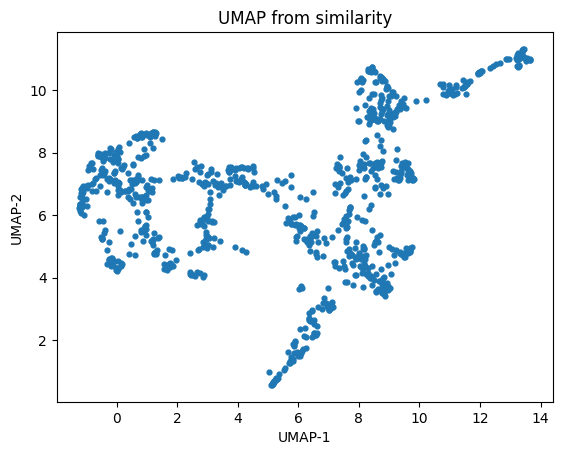

In [ ]:
D = 1 - matriz_similitud
Y = umap.UMAP(n_components=2, metric='precomputed', random_state=0).fit_transform(D)

plt.scatter(Y[:,0], Y[:,1], s=12)
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.title("UMAP from similarity"); plt.show()

Referencias:

1. RDKit Documentation: https://www.rdkit.org/docs/

2. Shervashidze@tuebingen, Nino, et al. “Weisfeiler-Lehman Graph Kernels Nino Shervashidze Kurt Mehlhorn Karsten M. Borgwardt.” Journal of Machine Learning Research, vol. 12, 2011, pp. 2539–2561, www.jmlr.org/papers/volume12/shervashidze11a/shervashidze11a.pdf.

3. Yuan-Sen Ting, and Bhavesh Sharma. “Weisfeiler-Lehman Graph Kernel Method:  ANewApproach to Weak Chemical Tagging.” Https://Arxiv.org/Pdf/2306.14206.